In [ ]:
import re
from collections import Counter
from pathlib import Path

# 1. PII Regex patterns (we will search for these in the answers)
ANSWER_PATTERNS = {
    'email_address': r'[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+',

    'phone_number': r'(?:(?:\+|00)\d{1,3}[\s-]?)?(?:\(?\d{2,5}\)?[\s-]?)?\d{3,4}[\s-]?\d{3,4}',

    'money_amount': r'(?:[\$€£]|USD|EUR)\s?\d+(?:,\d{3})*(?:\.\d{2})?|\d+(?:,\d{3})*(?:\.\d{2})?\s?(?:USD|EUR|dollars|euros)',

    'date': r'\b\d{4}[-/]\d{1,2}[-/]\d{1,2}\b|\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b|\b\d{1,2}\.\d{1,2}\.\d{2,4}\b|\b(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)[a-z]* \d{1,2},? \d{4}\b'
}
# Standard English stopwords that we want to exclude from the count
STOPWORDS = {
    "what", "is", "the", "of", "how", "many", "show", "shows", "in", "on", "to",
    "for", "a", "an", "are", "do", "you", "does", "which", "there", "it", "this",
    "can", "i", "be", "with", "and", "from", "at", "as", "has"
}

def get_ngrams(text, n=1):
    """Cleans the text and returns unigrams or bigrams."""
    # Extract only alphabetic words longer than 1 character
    words = re.findall(r'\b[a-z]{2,}\b', text.lower())
    words = [w for w in words if w not in STOPWORDS]

    if n == 1:
        return words
    else:
        # Generate bigrams (combinations of two consecutive words)
        return [f"{words[i]} {words[i+1]}" for i in range(len(words)-1)]

# 2. Read the generated file
file_path = Path('/content/drive/MyDrive/VU_DL_Team_Project/rico_full_qa.txt')

matched_questions = {k: [] for k in ANSWER_PATTERNS}

print("Analyzing text...")
with open(file_path, 'r', encoding='utf-8') as f:
    blocks = f.read().split('\n\n')

# 3. Filter using Regex
for block in blocks:
    if 'Q: ' in block and 'A: ' in block:
        lines = block.split('\n')
        q = lines[0].replace('Q: ', '')
        a = lines[1].replace('A: ', '')

        for category, pattern in ANSWER_PATTERNS.items():
            if re.search(pattern, a, re.IGNORECASE):
                matched_questions[category].append(q)

# 4. Print the results
for category, questions in matched_questions.items():
    print(f"\n{'='*40}")
    print(f"CATEGORY: {category.upper()} (Matches found: {len(questions)})")
    print(f"{'='*40}")

    unigrams = Counter()
    bigrams = Counter()

    for q in questions:
        unigrams.update(get_ngrams(q, 1))
        bigrams.update(get_ngrams(q, 2))

    print("TOP 50 Words (Unigrams):")
    for word, count in unigrams.most_common(50):
        print(f"  - {word}: {count}")

    print("\nTOP 50 Phrases (Bigrams):")
    for phrase, count in bigrams.most_common(50):
        print(f"  - {phrase}: {count}")

Analyzing text...

CATEGORY: EMAIL_ADDRESS (Matches found: 1674)
TOP 50 Words (Unigrams):
  - address: 1533
  - email: 1457
  - user: 161
  - gmail: 130
  - used: 104
  - given: 102
  - id: 78
  - account: 58
  - mail: 55
  - google: 41
  - contact: 34
  - support: 25
  - entered: 21
  - by: 20
  - sign: 14
  - application: 12
  - mentioned: 11
  - any: 11
  - log: 10
  - username: 9
  - shown: 9
  - login: 9
  - customer: 8
  - name: 8
  - app: 7
  - selected: 6
  - information: 6
  - we: 6
  - use: 6
  - if: 6
  - screen: 5
  - provided: 5
  - that: 5
  - up: 5
  - have: 5
  - been: 4
  - suggestions: 4
  - send: 4
  - feedback: 4
  - security: 4
  - website: 4
  - sam: 4
  - crawler: 4
  - assistance: 4
  - place: 3
  - sender: 3
  - where: 3
  - service: 3
  - comments: 3
  - john: 3

TOP 50 Phrases (Bigrams):
  - email address: 1375
  - address user: 101
  - gmail address: 95
  - address used: 89
  - email id: 63
  - given email: 61
  - mail address: 49
  - google mail: 32
  - gma

In [ ]:
import random
import re
from pathlib import Path

# File path
file_path = Path('/content/drive/MyDrive/VU_DL_Team_Project/rico_full_qa.txt')

# All V2 and V5 keywords from the table
all_keywords = [
    'email', 'mail',
    'phone', 'mobile', 'call', 'contact', 'cell',
    'balance', 'net worth', 'transaction', 'payment', 'charge', 'purchase', 'price', 'cost', 'fee',
    'first name', 'last name', 'full name', 'display name', 'who', 'author',
    'username', 'user id', 'login name', 'user',
    'address', 'street', 'zip', 'postal', 'location', 'city', 'country', 'destination',
    'date of birth', 'dob', 'birthday', 'born', 'age',
    'gender'
]

print("Reading file for all keywords check...")
with open(file_path, 'r', encoding='utf-8') as f:
    # Filter out empty blocks
    blocks = [b for b in f.read().split('\n\n') if b.strip()]

for word in all_keywords:
    matches = []
    for b in blocks:
        if 'Q: ' in b and 'A: ' in b:
            # Extract just the question part and convert to lowercase
            q_text = b.split('\nA:')[0].lower()

            # Use Regex \b to match exact whole words only (ignores punctuation)
            if re.search(rf'\b{word}\b', q_text):
                matches.append(b)

    # Take up to 10 random samples
    sample_size = min(10, len(matches))
    sample = random.sample(matches, sample_size)

    print(f"\n{'='*60}")
    print(f"KEYWORD: '{word.upper()}' (Total questions found: {len(matches)})")
    print(f"{'='*60}")

    if not sample:
         print("  No matches found.")

    for i, b in enumerate(sample, 1):
        clean_block = b.replace('\n', ' | ')
        print(f"{i}. {clean_block}")

Reading file for all keywords check...

KEYWORD: 'EMAIL' (Total questions found: 1936)
1. Q: What is the email address? | A: The email address is appcrawler5@gmail.com.
2. Q: What is the email address? | A: The email address is appcrawler6@gmail.com.
3. Q: What is the email address? | A: The email address is appcrawler6@gmail.com.
4. Q: What is the email address? | A: The email address is appcrawler5@gmail.com.
5. Q: What is the email address? | A: The email address is appcrawler4@gmail.com.
6. Q: What is the email address of the author? | A: The email address of the author is kapelis.aristidis@gmail.com.
7. Q: What is the email address of the user? | A: The email address is appcrawler4@gmail.com.
8. Q: What applications can be used to select email application? | A: The applications are "Facebook", "Messaging", "Fake GPS - Search location", "Android Beam" and "Bluetooth".
9. Q: What is the given email address? | A: The given email address is appcrawler5@gmail.com.
10. Q: What is the em

In [ ]:
import random
import re
from pathlib import Path

# File path
file_path = Path('/content/drive/MyDrive/VU_DL_Team_Project/rico_full_qa.txt')

# New proposed keywords/bigrams from the Top 50 N-gram analysis
new_keywords_to_test = {
    'EMAIL_ADDRESS_NEW': ['gmail', 'id', 'support', 'gmail address', 'email id'],
    'PHONE_NUMBER_NEW': ['helpline', 'service', 'care', 'customer service', 'helpline number'],
    'MONEY_AMOUNT_NEW': ['total', 'subscription', 'discount', 'rent', 'pay'],
    'DATE_NOISE_CHECK': ['posted', 'version', 'published', 'news', 'article']
}

print("Reading file for new proposed keywords check...")
with open(file_path, 'r', encoding='utf-8') as f:
    blocks = [b for b in f.read().split('\n\n') if b.strip()]

for category, words in new_keywords_to_test.items():
    print(f"\n{'#'*70}")
    print(f"--- TESTING CATEGORY: {category} ---")
    print(f"{'#'*70}")

    for word in words:
        matches = []
        for b in blocks:
            if 'Q: ' in b and 'A: ' in b:
                # Extract the question part and convert to lowercase
                q_text = b.split('\nA:')[0].lower()

                # Use Regex \b to match exact whole words or phrases
                if re.search(rf'\b{word}\b', q_text):
                    matches.append(b)

        # Take exactly 5 random samples
        sample_size = min(10, len(matches))
        sample = random.sample(matches, sample_size)

        print(f"\n{'='*60}")
        print(f"KEYWORD: '{word.upper()}' (Total questions found: {len(matches)})")
        print(f"{'-'*60}")

        if not sample:
             print("  No matches found.")

        for i, b in enumerate(sample, 1):
            clean_block = b.replace('\n', ' | ')
            print(f"{i}. {clean_block}")

Reading file for new proposed keywords check...

######################################################################
--- TESTING CATEGORY: EMAIL_ADDRESS_NEW ---
######################################################################

KEYWORD: 'GMAIL' (Total questions found: 134)
------------------------------------------------------------
1. Q: What Gmail address can be used for log in? | A: The Gmail address that can be used to log in is appcrawler1@gmail.com.
2. Q: What Gmail address is used? | A: The Gmail address is appcrawler2@gmail.com.
3. Q: What is the Gmail account address? | A: The Gmail account address is appcrawler5@gmail.com.
4. Q: What's the Gmail address? | A: The Gmail address is salasarford@gmail.com.
5. Q: What is the Gmail address? | A: The Gmail address is appcrawler2@gmail.com.
6. Q: What is the Gmail address? | A: The Gmail address is appcrawler3@gmail.com.
7. Q: What Gmail address is used? | A: The used Gmail address is jacky.finalfantasy@gmail.com.
8. Q: What 

In [ ]:
import re
from collections import Counter
from pathlib import Path

# File path
file_path = Path('/content/drive/MyDrive/VU_DL_Team_Project/rico_full_qa.txt')

# Flattened list of all approved keywords from V6 to exclude them from the search
# We also split bigrams into unigrams to ensure parts like "address" or "name" are ignored
EXISTING_KEYWORDS = {
    'email', 'mail', 'gmail', 'address', 'id',
    'phone', 'contact', 'helpline', 'number',
    'balance', 'account', 'charge', 'price', 'cost', 'fee', 'rent',
    'transaction', 'payment', 'total', 'purchase', 'amount', 'monthly',
    'first', 'last', 'full', 'display', 'name',
    'username', 'login', 'user',
    'street', 'zip', 'postal', 'location', 'city', 'country', 'destination',
    'date', 'birth', 'dob', 'birthday', 'born', 'age',
    'gender', 'password', 'passcode', 'pin'
}

# Extended standard stopwords
STOPWORDS = {
    "what", "is", "the", "of", "how", "many", "show", "shows", "in", "on", "to",
    "for", "a", "an", "are", "do", "you", "your", "does", "which", "there", "it", "this",
    "can", "i", "be", "with", "and", "from", "at", "as", "has", "have", "that", "was",
    "whats", "what's"
}

# Combine both sets to filter them out completely
WORDS_TO_IGNORE = EXISTING_KEYWORDS.union(STOPWORDS)

def get_cleaned_words(text):
    """Extracts alphabetic words and filters out stopwords and known keywords."""
    words = re.findall(r'\b[a-z]{2,}\b', text.lower())
    return [w for w in words if w not in WORDS_TO_IGNORE]

def get_bigrams(words):
    """Generates bigrams from a list of words."""
    return [f"{words[i]} {words[i+1]}" for i in range(len(words)-1)]

unigrams = Counter()
bigrams = Counter()

print("Reading file and analyzing question patterns...")
with open(file_path, 'r', encoding='utf-8') as f:
    blocks = [b for b in f.read().split('\n\n') if b.strip()]

for block in blocks:
    if 'Q: ' in block:
        # Extract question line
        q_line = block.split('\nA:')[0].replace('Q: ', '').strip()
        q_lower = q_line.lower()

        # Look for target starting phrases
        if (q_lower.startswith("what is the") or
            q_lower.startswith("what is your") or
            q_lower.startswith("what's the") or
            q_lower.startswith("what's your")):

            cleaned_words = get_cleaned_words(q_line)

            if cleaned_words:
                unigrams.update(cleaned_words)
                bigrams.update(get_bigrams(cleaned_words))

print(f"\n{'='*40}")
print("TOP 100 UNIGRAMS (Potential New PII)")
print(f"{'='*40}")
for word, count in unigrams.most_common(100):
    print(f"  - {word}: {count}")

print(f"\n{'='*40}")
print("TOP 50 BIGRAMS (Potential New PII)")
print(f"{'='*40}")
for phrase, count in bigrams.most_common(100):
    print(f"  - {phrase}: {count}")

Reading file and analyzing question patterns...

TOP 100 UNIGRAMS (Potential New PII)
  - application: 8254
  - status: 4264
  - selected: 2311
  - time: 2179
  - duration: 1220
  - app: 1115
  - given: 1057
  - version: 947
  - current: 883
  - temperature: 698
  - mentioned: 671
  - rating: 536
  - setting: 533
  - code: 514
  - day: 488
  - count: 483
  - shown: 482
  - percentage: 480
  - option: 453
  - screen: 433
  - size: 410
  - tab: 371
  - video: 335
  - news: 317
  - year: 308
  - unit: 305
  - title: 303
  - weight: 289
  - notifications: 274
  - profile: 270
  - song: 269
  - distance: 261
  - alerts: 248
  - entered: 236
  - value: 234
  - article: 233
  - weather: 233
  - range: 232
  - speed: 230
  - by: 219
  - new: 217
  - type: 216
  - score: 210
  - currency: 206
  - language: 201
  - level: 200
  - notification: 200
  - set: 199
  - text: 193
  - departure: 183
  - person: 181
  - my: 170
  - sound: 169
  - movie: 166
  - audio: 166
  - length: 165
  - mode: 157
 

In [ ]:
import re
from collections import Counter
from pathlib import Path

# File path
file_path = Path('/content/drive/MyDrive/VU_DL_Team_Project/rico_full_qa.txt')

# Flattened list of all approved keywords from V6, plus weight/height
EXISTING_KEYWORDS = {
    'email', 'mail', 'gmail', 'address', 'id',
    'phone', 'contact', 'helpline', 'number',
    'balance', 'account', 'charge', 'price', 'cost', 'fee', 'rent',
    'transaction', 'payment', 'total', 'purchase', 'amount', 'monthly',
    'first', 'last', 'full', 'display', 'name',
    'username', 'login', 'user',
    'street', 'zip', 'postal', 'location', 'city', 'country', 'destination',
    'date', 'birth', 'dob', 'birthday', 'born', 'age',
    'gender', 'password', 'passcode', 'pin', 'weight', 'height'
}

# Extended standard stopwords
STOPWORDS = {
    "what", "is", "the", "of", "how", "many", "show", "shows", "in", "on", "to",
    "for", "a", "an", "are", "do", "you", "your", "does", "which", "there", "it", "this",
    "can", "i", "be", "with", "and", "from", "at", "as", "has", "have", "that", "was",
    "whats", "what's"
}

# Combine both sets to filter them out completely
WORDS_TO_IGNORE = EXISTING_KEYWORDS.union(STOPWORDS)

def get_cleaned_words(text):
    """Extracts alphabetic words and filters out stopwords and known keywords."""
    words = re.findall(r'\b[a-z]{2,}\b', text.lower())
    return [w for w in words if w not in WORDS_TO_IGNORE]

def get_trigrams(words):
    """Generates trigrams from a list of words."""
    return [f"{words[i]} {words[i+1]} {words[i+2]}" for i in range(len(words)-2)]

trigrams = Counter()

print("Reading file and analyzing trigram patterns...")
with open(file_path, 'r', encoding='utf-8') as f:
    blocks = [b for b in f.read().split('\n\n') if b.strip()]

for block in blocks:
    if 'Q: ' in block:
        # Extract question line
        q_line = block.split('\nA:')[0].replace('Q: ', '').strip()
        q_lower = q_line.lower()

        # Look for target starting phrases
        if (q_lower.startswith("what is the") or
            q_lower.startswith("what is your") or
            q_lower.startswith("what's the") or
            q_lower.startswith("what's your")):

            cleaned_words = get_cleaned_words(q_line)

            # We need at least 3 valid words to form a trigram
            if len(cleaned_words) >= 3:
                trigrams.update(get_trigrams(cleaned_words))

print(f"\n{'='*40}")
print("TOP 30 TRIGRAMS (Potential New PII)")
print(f"{'='*40}")
for phrase, count in trigrams.most_common(50):
    print(f"  - {phrase}: {count}")

Reading file and analyzing trigram patterns...

TOP 30 TRIGRAMS (Potential New PII)
  - status option includes: 56
  - status remember me: 50
  - severe weather alerts: 46
  - status lightning alerts: 42
  - status request desktop: 41
  - request desktop site: 41
  - status push notifications: 41
  - status severe weather: 38
  - option includes agreement: 38
  - temperature shown screen: 36
  - version application being: 35
  - application being used: 35
  - selected item menu: 32
  - status keep me: 28
  - time duration video: 27
  - includes agreement terms: 27
  - year copyright application: 25
  - time duration song: 23
  - status station alerts: 22
  - status night mode: 22
  - minimum font size: 20
  - time shown screen: 19
  - status keep screen: 18
  - option includes acceptance: 18
  - current playing song: 18
  - status force enable: 18
  - force enable zoom: 18
  - unit wind speed: 18
  - status breaking news: 17
  - zoom double tap: 17
  - status weather alerts: 16
  - art

In [ ]:
import re

# Sukompiliuoti Regex šablonai kiekvienam labeliui
REGEX_KEYWORD_MAP = {
    # Pagauna: email, mail, gmail, email address, gmail address, email id
    'email_address': re.compile(r'\b(?:email|mail|gmail)(?:\s+(?:address|id))?\b', re.IGNORECASE),

    # Pagauna: phone, contact, helpline, phone number, contact number, helpline number
    'phone_number': re.compile(r'\b(?:phone|contact|helpline)(?:\s+number)?\b', re.IGNORECASE),

    # Pagauna tik: balance, account balance
    'account_balance': re.compile(r'\b(?:account\s+)?balance\b', re.IGNORECASE),

    # Pagauna pavienius: charge, price, cost, fee, rent
    # BEI kombinacijas: transaction amount, payment amount, total amount, total price, purchase price, monthly payment
    'transaction_amount': re.compile(r'\b(?:charge|price|cost|fee|rent)\b|\b(?:transaction|payment|total|purchase|monthly)\s+(?:amount|price|cost|payment)\b', re.IGNORECASE),

    # Pagauna: first name, last name, full name, display name
    'full_name': re.compile(r'\b(?:first|last|full|display)\s+name\b', re.IGNORECASE),

    # Pagauna: username, login name, user id
    'username': re.compile(r'\b(?:username|login\s+name|user\s+id)\b', re.IGNORECASE),

    # Pagauna: address, street, zip, postal, location, city, country, destination
    'address': re.compile(r'\b(?:address|street|zip|postal|location|city|country|destination)\b', re.IGNORECASE),

    # Pagauna: date of birth, dob, birthday, born, age
    'date_of_birth': re.compile(r'\b(?:date\s+of\s+birth|dob|birthday|born|age)\b', re.IGNORECASE),

    # Pagauna: gender, password, passcode, pin, weight, height
    'other_sensitive': re.compile(r'\b(?:gender|password|passcode|pin|weight|height)\b', re.IGNORECASE)
}

def assign_labels(question_text):
    """Funkcija, kuri priskiria labelius klausimui pagal Regex."""
    assigned_labels = []
    for label, pattern in REGEX_KEYWORD_MAP.items():
        if pattern.search(question_text):
            assigned_labels.append(label)
    return assigned_labels

# Example:
test_queries = [
    "What is the transaction amount?", # Pagaus 'transaction_amount'
    "What is the transaction ID?",     # Nepagaus nieko (išfiltruotas triukšmas)
    "Please enter your mobile phone.", # Pagaus 'phone_number'
    "What is the user's height?"       # Pagaus 'other_sensitive'
]

for q in test_queries:
    print(f"Q: '{q}' -> Labels: {assign_labels(q)}")

Q: 'What is the transaction amount?' -> Labels: ['transaction_amount']
Q: 'What is the transaction ID?' -> Labels: []
Q: 'Please enter your mobile phone.' -> Labels: ['phone_number']
Q: 'What is the user's height?' -> Labels: ['other_sensitive']


In [ ]:
import re
from datasets import load_dataset
from collections import Counter
from tqdm.auto import tqdm
from pathlib import Path

# ==========================================
# 1. OUR VALIDATED REGEX KEYWORD MAP (V6 + Biometrics)
# ==========================================
REGEX_KEYWORD_MAP = {
    'email_address': re.compile(r'\b(?:email|mail|gmail)(?:\s+(?:address|id))?\b', re.IGNORECASE),
    'phone_number': re.compile(r'\b(?:phone|contact|helpline)(?:\s+number)?\b', re.IGNORECASE),
    'account_balance': re.compile(r'\b(?:account\s+)?balance\b', re.IGNORECASE),
    'transaction_amount': re.compile(r'\b(?:charge|price|cost|fee|rent)\b|\b(?:transaction|payment|total|purchase|monthly)\s+(?:amount|price|cost|payment)\b', re.IGNORECASE),
    'full_name': re.compile(r'\b(?:first|last|full|display)\s+name\b', re.IGNORECASE),
    'username': re.compile(r'\b(?:username|login\s+name|user\s+id)\b', re.IGNORECASE),
    'address': re.compile(r'\b(?:address|street|zip|postal|location|city|country|destination)\b', re.IGNORECASE),
    'date_of_birth': re.compile(r'\b(?:date\s+of\s+birth|dob|birthday|born|age)\b', re.IGNORECASE),
    'other_sensitive': re.compile(r'\b(?:gender|password|passcode|pin|weight|height)\b', re.IGNORECASE)
}

def classify_question(question_text):
    """
    Scans the question against our regex patterns.
    Returns the first matched label, or None if no PII is found.
    """
    for label, pattern in REGEX_KEYWORD_MAP.items():
        if pattern.search(question_text):
            return label
    return None

# ==========================================
# 2. DATASET PROCESSING PARAMETERS
# ==========================================
MAX_NEG_SAVE = 3_000
MIN_BBOX_PX  = 4

# Ensure IMG_DIR is defined (Modify to your actual path)
IMG_DIR = Path('./rico_images')
IMG_DIR.mkdir(parents=True, exist_ok=True)

PHASE1_LABELS = {'email_address', 'phone_number', 'full_name', 'address', 'date_of_birth'}

screen_data    = {}
neg_candidates = {}
matched_qa     = 0
skipped_qa     = 0
img_errors     = 0
label_counter  = Counter()
eda_all_questions = []
eda_bbox_per_qa   = []
eda_widths        = []
eda_heights       = []

def validate_bbox(bounds, img_w, img_h):
    if not bounds or len(bounds) != 4:
        return None
    x1, y1, x2, y2 = bounds
    if (x2 - x1) < MIN_BBOX_PX or (y2 - y1) < MIN_BBOX_PX:
        return None
    # Clip bounds to image dimensions
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(img_w, x2), min(img_h, y2)
    return [x1, y1, x2, y2]

# ==========================================
# 3. MAIN DOWNLOADER LOOP
# ==========================================
for split_name in ['train', 'validation', 'test']:
    print(f'\nProcessing {split_name}...')
    ds = load_dataset(
        'rootsautomation/RICO-ScreenQA',
        split=split_name,
        streaming=True,
    )

    for row in tqdm(ds, desc=split_name):
        screen_id = str(row['screen_id'])
        question  = row['question']
        img       = row['image']
        w, h      = img.width, img.height

        eda_all_questions.append(question)
        n_bboxes = sum(
            len(gt.get('ui_elements', []))
            for gt in row.get('ground_truth', [])
        )
        eda_bbox_per_qa.append(n_bboxes)

        # Apply robust regex classification
        label = classify_question(question)

        if label:
            seen = set()
            new_objs = []
            for gt in row.get('ground_truth', []):
                ans = gt.get('full_answer', '')
                for elem in gt.get('ui_elements', []):
                    bbox = validate_bbox(elem.get('bounds'), w, h)
                    if bbox is None:
                        continue
                    key = tuple(bbox)
                    if key in seen:
                        continue
                    seen.add(key)
                    new_objs.append({
                        'bbox':            bbox,
                        'label':           label,
                        'source_question': question,
                        'source_answer':   ans,
                    })

            if new_objs:
                if screen_id not in screen_data:
                    img_path = IMG_DIR / f'{screen_id}.png'
                    try:
                        img.save(img_path, format='PNG')
                        screen_data[screen_id] = {
                            'objects':      [],
                            'image_width':  w,
                            'image_height': h,
                        }
                        eda_widths.append(w)
                        eda_heights.append(h)
                        neg_candidates.pop(screen_id, None)
                    except Exception:
                        img_errors += 1
                        img.close()
                        skipped_qa += 1
                        continue

                screen_data[screen_id]['objects'].extend(new_objs)
                label_counter[label] += len(new_objs)
                matched_qa += 1
                img.close()
                continue

        # Save negative candidates (screens without matching PII)
        if (screen_id not in screen_data and
            screen_id not in neg_candidates and
            len(neg_candidates) < MAX_NEG_SAVE):
            img_path = IMG_DIR / f'{screen_id}.png'
            try:
                img.save(img_path, format='PNG')
                neg_candidates[screen_id] = {'image_width': w, 'image_height': h}
            except Exception:
                img_errors += 1

        img.close()
        skipped_qa += 1

# ==========================================
# 4. DEDUPLICATION AND REPORTING
# ==========================================
for sid in screen_data:
    seen = set()
    unique = []
    for obj in screen_data[sid]['objects']:
        key = (tuple(obj['bbox']), obj['label'])
        if key not in seen:
            seen.add(key)
            unique.append(obj)
    screen_data[sid]['objects'] = unique

neg_candidates = {
    sid: meta for sid, meta in neg_candidates.items()
    if sid not in screen_data
}

pii_screen_ids = list(screen_data.keys())

print(f'\nMatched QA    : {matched_qa:,}')
print(f'Skipped QA    : {skipped_qa:,}')
print(f'PII screens   : {len(pii_screen_ids):,}')
print(f'Neg candidates: {len(neg_candidates):,}')
print(f'Image errors  : {img_errors}')
print()
for l, c in sorted(label_counter.items(), key=lambda x: -x[1]):
    print(f'  {"P1" if l in PHASE1_LABELS else "P2"}  {l:<25s}: {c:5d}')


Processing train...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

...


Processing test...


Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

test: 0it [00:00, ?it/s]


Matched QA    : 11,165
Skipped QA    : 74,860
PII screens   : 7,614
Neg candidates: 3,000
Image errors  : 0

  P1  address                  :  3961
  P2  transaction_amount       :  2943
  P1  email_address            :  2460
  P2  other_sensitive          :  1596
  P1  date_of_birth            :  1127
  P1  phone_number             :  1021
  P2  username                 :   712
  P1  full_name                :   253
  P2  account_balance          :   191


In [ ]:
import json
import random
from collections import Counter, defaultdict

# ==========================================
# 1. PREPARE ALL SCREENS (WITH AND WITHOUT PII)
# ==========================================
pii_screens = list(screen_data.keys())

# The schema requests ~10-20% empty (negative) examples.
target_neg_count = int(len(pii_screens) * 0.15) # 15% negative examples
available_negs = list(neg_candidates.keys())

random.seed(42)
random.shuffle(available_negs)
selected_negs = available_negs[:target_neg_count]

all_screens = pii_screens + selected_negs

# ==========================================
# 2. MULTI-LABEL STRATIFICATION (Rarest Label Heuristic)
# ==========================================
print("Calculating label frequencies for stratified splitting...")

# Count global frequencies of all labels to identify the rarest ones
label_counts = Counter()
for sid in pii_screens:
    for obj in screen_data[sid]['objects']:
        label_counts[obj['label']] += 1

# Assign a "primary label" to each screen (the rarest label it contains)
screen_primary_label = {}
for sid in all_screens:
    if sid in screen_data:
        screen_labels = [obj['label'] for obj in screen_data[sid]['objects']]
        # Sort labels by global frequency (ascending) and pick the first (rarest)
        rarest_label = sorted(screen_labels, key=lambda l: label_counts[l])[0]
        screen_primary_label[sid] = rarest_label
    else:
        screen_primary_label[sid] = "NEGATIVE_EXAMPLE"

# Group screen IDs by their assigned primary label
grouped_screens = defaultdict(list)
for sid, label in screen_primary_label.items():
    grouped_screens[label].append(sid)

# ==========================================
# 3. SPLIT EACH GROUP 80/10/10
# ==========================================
splits = {'train': [], 'val': [], 'test': []}

for label, sids in grouped_screens.items():
    random.shuffle(sids)
    total = len(sids)
    train_idx = int(0.8 * total)
    val_idx = int(0.9 * total)

    splits['train'].extend(sids[:train_idx])
    splits['val'].extend(sids[train_idx:val_idx])
    splits['test'].extend(sids[val_idx:])

# Shuffle the final splits so classes are randomly distributed during training
for split_name in splits:
    random.shuffle(splits[split_name])

# ==========================================
# 4. GENERATE JSONL FILES MATCHING SCHEMA.MD
# ==========================================
print("Generating model-agnostic JSONL files according to SCHEMA.md...")

for split_name, ids in splits.items():
    output_data = []

    for sid in ids:
        if sid in screen_data:
            w = screen_data[sid]['image_width']
            h = screen_data[sid]['image_height']
            objects = screen_data[sid]['objects']
        else:
            w = neg_candidates[sid]['image_width']
            h = neg_candidates[sid]['image_height']
            objects = []

        entry = {
            "image": f"images/{sid}.png",
            "image_width": w,
            "image_height": h,
            "screen_id": str(sid),
            "objects": []
        }

        for obj in objects:
            entry["objects"].append({
                "bbox": obj['bbox'],
                "label": obj['label'],
                "source_question": obj['source_question'],
                "source_answer": obj['source_answer']
            })

        output_data.append(entry)

    file_name = f"{split_name}.jsonl"
    with open(file_name, 'w', encoding='utf-8') as f:
        for item in output_data:
            f.write(json.dumps(item) + '\n')

    print(f"Saved: {file_name} (Screens: {len(ids)})")

print("\nData preparation complete!")

Calculating label frequencies for stratified splitting...
Generating model-agnostic JSONL files according to SCHEMA.md...
Saved: train.jsonl (Screens: 6999)
Saved: val.jsonl (Screens: 875)
Saved: test.jsonl (Screens: 882)

Data preparation complete!


Loading generated JSONL files for EDA...


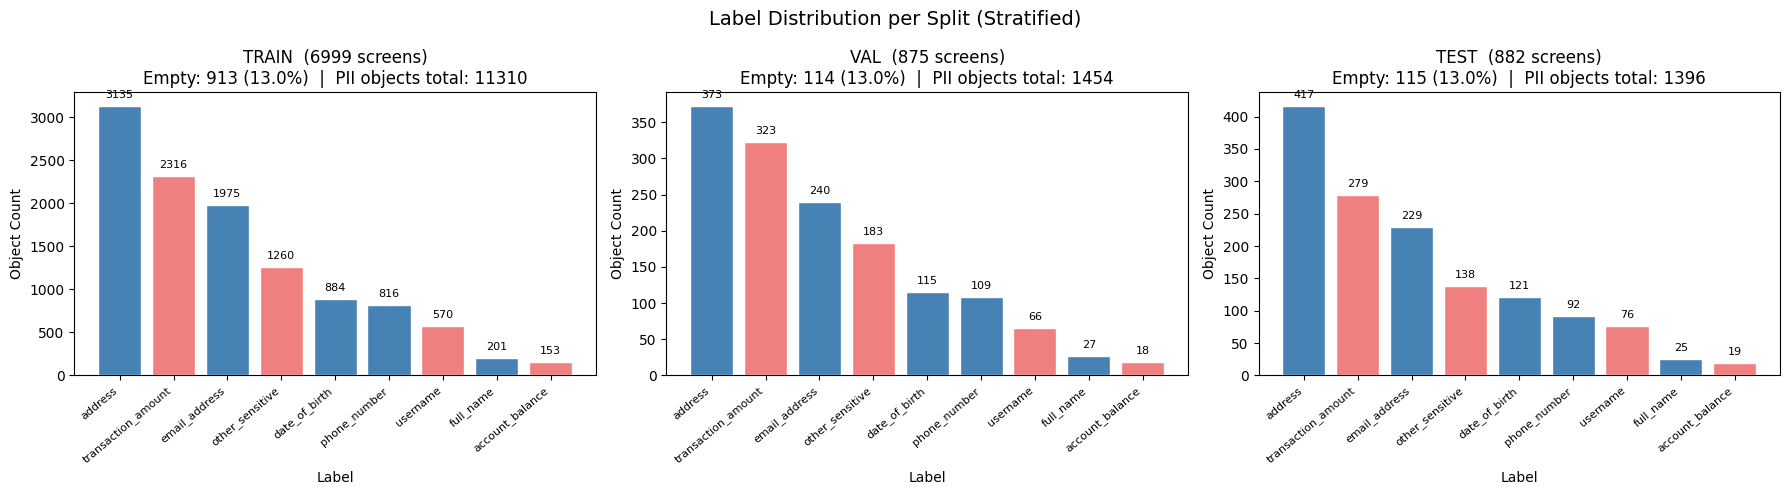


Label                        Train      Val     Test
-------------------------------------------------------
P2 account_balance              153       18       19
P1 address                     3135      373      417
P1 date_of_birth                884      115      121
P1 email_address               1975      240      229
P1 full_name                    201       27       25
P2 other_sensitive             1260      183      138
P1 phone_number                 816      109       92
P2 transaction_amount          2316      323      279
P2 username                     570       66       76
-------------------------------------------------------
Total screens                 6999      875      882
Empty screens (Negative)       913      114      115


In [ ]:
import json
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

# ==========================================
# 1. LOAD GENERATED JSONL FILES
# ==========================================
splits = ['train', 'val', 'test']
split_map = {}

# Define Phase 1 labels for color-coding in plots
PHASE1_LABELS = {'email_address', 'phone_number', 'full_name', 'address', 'date_of_birth'}

print("Loading generated JSONL files for EDA...")
for split in splits:
    file_path = f"{split}.jsonl"
    entries = []
    if Path(file_path).exists():
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                entries.append(json.loads(line))
    else:
        print(f"Warning: {file_path} not found.")
    split_map[split] = entries

# ==========================================
# 2. PLOT LABEL DISTRIBUTIONS
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (split_name, entries) in zip(axes, split_map.items()):
    if not entries:
        ax.set_title(f"{split_name.upper()} (No Data)")
        continue

    # Flatten all labels from the objects array
    labels = [obj["label"] for e in entries for obj in e["objects"]]
    lc = Counter(labels)
    n_empty = sum(1 for e in entries if not e["objects"])
    n_total = len(entries)

    # Sort labels by frequency (descending)
    ls = sorted(lc.keys(), key=lambda k: -lc[k])
    cl = ["steelblue" if l in PHASE1_LABELS else "lightcoral" for l in ls]

    if ls: # Prevent plotting errors if a split has only empty screens
        bars = ax.bar(ls, [lc[l] for l in ls], color=cl, edgecolor="white")

        # Add numeric labels above bars with dynamic offset
        max_height = max(lc.values())
        for bar, l in zip(bars, ls):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + (max_height * 0.03),
                    str(lc[l]), ha="center", fontsize=8)

    ax.set_title(
        f"{split_name.upper()}  ({n_total} screens)\n"
        f"Empty: {n_empty} ({n_empty/n_total*100:.1f}%)  |  "
        f"PII objects total: {sum(lc.values())}"
    )
    ax.set_xlabel("Label")
    ax.set_ylabel("Object Count")

    # Set explicit x-ticks to avoid Matplotlib warnings
    ax.set_xticks(range(len(ls)))
    ax.set_xticklabels(ls, rotation=40, ha="right", fontsize=8)

plt.suptitle("Label Distribution per Split (Stratified)", fontsize=14)
plt.tight_layout()
plt.savefig("eda_per_split.png", dpi=120)
plt.show()

# ==========================================
# 3. PRINT SUMMARY TABLE
# ==========================================
print(f"\n{'Label':<25s} {'Train':>8s} {'Val':>8s} {'Test':>8s}")
print("-" * 55)

# Get all unique labels across all splits
all_ls = sorted(set(
    obj["label"]
    for entries in split_map.values()
    for e in entries
    for obj in e["objects"]
))

for l in all_ls:
    counts = {
        split: sum(1 for e in entries for obj in e["objects"] if obj["label"] == l)
        for split, entries in split_map.items()
    }
    p1p2 = "P1" if l in PHASE1_LABELS else "P2"
    print(f"{p1p2} {l:<23s} {counts['train']:>8d} {counts['val']:>8d} {counts['test']:>8d}")

print("-" * 55)
print(f"{'Total screens':<25s} "
      f"{len(split_map.get('train', [])):>8d} "
      f"{len(split_map.get('val', [])):>8d} "
      f"{len(split_map.get('test', [])):>8d}")

print(f"{'Empty screens (Negative)':<25s} "
      f"{sum(1 for e in split_map.get('train', []) if not e['objects']):>8d} "
      f"{sum(1 for e in split_map.get('val', []) if not e['objects']):>8d} "
      f"{sum(1 for e in split_map.get('test', []) if not e['objects']):>8d}")

In [ ]:
import os
import shutil
from pathlib import Path
from google.colab import drive

# ==========================================
# 1. MOUNT GOOGLE DRIVE
# ==========================================
print("Mounting Google Drive...")
drive.mount('/content/drive')

# ==========================================
# 2. DEFINE PATHS
# ==========================================
LOCAL_IMG_DIR = '/content/rico_images'
DRIVE_DEST_DIR = Path('/content/drive/MyDrive/VU_DL_Team_Project/data/pii_v5')
DRIVE_DEST_DIR.mkdir(parents=True, exist_ok=True)

# ==========================================
# 3. ZIP IMAGES
# ==========================================
print("\nZipping images...")
shutil.make_archive('/content/images', 'zip', LOCAL_IMG_DIR)
print("Images zipped successfully!")

# ==========================================
# 4. UPLOAD FILES TO DRIVE
# ==========================================
print(f"\nUploading files to: {DRIVE_DEST_DIR}")

files_to_upload = [
    '/content/train.jsonl',
    '/content/val.jsonl',
    '/content/test.jsonl',
    '/content/images.zip'
]

for file_path in files_to_upload:
    if os.path.exists(file_path):
        file_name = os.path.basename(file_path)
        dest_path = DRIVE_DEST_DIR / file_name
        print(f"Uploading {file_name}...")
        shutil.copy2(file_path, dest_path)
    else:
        print(f"ERROR: {file_path} not found! Did you run Cell 2?")

print("\nALL Data is now ready on Google Drive")

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Zipping images...
Images zipped successfully!

Uploading files to: /content/drive/MyDrive/VU_DL_Team_Project/data/pii_v5
Uploading train.jsonl...
Uploading val.jsonl...
Uploading test.jsonl...
Uploading images.zip...

ALL Data is now ready on Google Drive


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import nbformat
notebook_path = '/content/drive/MyDrive/Colab Notebooks/Untitled7.ipynb'

with open(notebook_path, 'r') as f:
    nb = nbformat.read(f, as_version=4)

nb.metadata.pop('widgets', None)

with open(notebook_path, 'w') as f:
    nbformat.write(nb, f)